## Figure: Agreement and Recource

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
from functools import partial
import logging

from monoculture.analysis.setup import (
    FIGURES_ROOT_DIR,
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
    observed_agreement_wrapper,
)
from monoculture.analysis.utils import (
    load_model_outputs_same_prompt,
    get_size_and_it,
    load_results_overview,
    add_evals_to_df,
    load_data_if_needed,
    filter_results,
    df_to_dict,
)

from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_lineplot,
    configure_legend
)


In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ["ACSIncome"]

In [4]:
select_by='accuracy' #'balanced_accuracy' #

## Load predictions ACSIncome

In [5]:
num_shots = 0
threshold_fitted = True

df = load_results_overview(
    num_shots=num_shots, threshold_fitted=threshold_fitted, same_prompt=True
)
df = df[df["task"].isin(TASKS)]
df.shape

(50, 15)

In [6]:
try:
    assert set(TASKS).issubset(
        set(df["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df['task'].unique())} "
except AssertionError:
    TASKS = list(df["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [7]:
predictions_all = load_model_outputs_same_prompt(
    df, tasks=TASKS, return_risk_scores=False
)

df = add_evals_to_df(df)

ACSIncome


## Restrict analysis to models based on performance or true labels?

In [8]:
try:
    data_all
except NameError:
    print("data not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

data not yet defined
ACSIncome


In [9]:
restrict_to_better_const = True
restrict_to_positive_label = True
restrict_to_negative_label = False
restrict_to_top_eps = True
eps = 0.05
restrict_to_topk = False
topk = 10

predictions, data = filter_results(
    predictions=predictions_all.copy(),
    df=df,
    data={t: val for t, val in data_all.items() if t in TASKS},
    tasks=TASKS,
    restrict_to_better_const=restrict_to_better_const,
    restrict_to_positive_label=restrict_to_positive_label,
    restrict_to_negative_label=restrict_to_negative_label,
    restrict_to_top_eps=restrict_to_top_eps,
    restrict_to_topk=restrict_to_topk,
    eps=eps,
    topk=topk,
    acc = select_by
)

Using accuracy for comparison.
ACSIncome (61233, 42)
ACSIncome (61233, 23)


## Plot

In [10]:
# helpers
def build_filename():
    parts = [
        f"agreement-recourse-{num_shots}-shot",
        f"-{TASKS[0]}",
        f"_selected_by-{select_by}"
        "_tresh_fitted" if threshold_fitted else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
    return "".join(parts)

def plot_agreement_wrapper(ax, predictions: pd.DataFrame, accuracies: dict):
    models_sorted = sorted(predictions.columns, key=get_size_and_it)
    M = len(models_sorted)

    obs_matrix = matrix_pairwise_evals(
        models_sorted, partial(observed_agreement_wrapper, predictions=predictions)
    ).fill_diagonal_(torch.nan)

    exp_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: pairwise_agreement_at_random(accuracies[m1], accuracies[m2]),
    ).fill_diagonal_(torch.nan)

    ax = plot_agreement_lineplot(
        ax,
        obs_matrix[~obs_matrix.isnan()],
        exp_matrix[~exp_matrix.isnan()],
        ylim=(0.45, 1.0),
    )

    print(f"mean agreement: {obs_matrix[~obs_matrix.isnan()].mean():.4f}")
    print(f"mean agreement at random: {exp_matrix[~exp_matrix.isnan()].mean():.4f}")

    ax.set_ylabel("agreement")
    ax.set_xlabel("fraction of model pairs")
    return ax


def plot_recourse_wrapper(ax, predictions, baseline_rates, y_true):
    return plot_recourse_lineplot(
        ax,
        predictions=predictions,
        baseline_rates=baseline_rates,
        y_true=y_true,
        restrict_only_pos_instances=True,
        restrict_only_neg_instances=False,
        count_accepted=True,
        at_least=False,
        plot_pdf=True,
        xlabel="fraction of positive instances",
        ylabel="fraction of models accepting",
        num_ticks=6,
    )

mean agreement: 0.8949
mean agreement at random: 0.6402
agreement-recourse-0-shot-ACSIncome_selected_by-accuracy_tresh_fitted_better_const_pos_instances_eps0_05


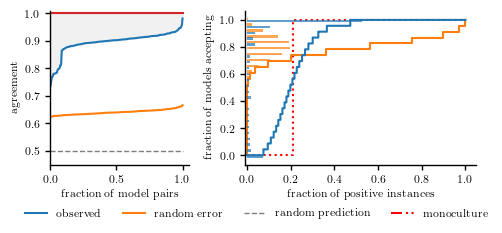

In [11]:
tasks_to_plot = TASKS 
selection_by = 'accuracy'

fig_width = plt.rcParams["figure.figsize"][0]
fig_height = 2 if num_shots == 0 else 1.5

fig, axs = plt.subplots(
    1,
    2,
    figsize=(fig_width, fig_height),
    # constrained_layout=True,
    gridspec_kw={"width_ratios": [3 / 8, 5 / 8], "wspace": 0.3},
)

for i, task in enumerate(tasks_to_plot):
    # agreement
    mask = (df["task"] == task) & (df["model"].isin(predictions[task].columns))
    acc_dict = df_to_dict(df[mask][["model", "accuracy"]])
    axs[0] = plot_agreement_wrapper(
        axs[0], predictions=predictions[task], accuracies=acc_dict
    )

    # recourse
    tp_rates = list(1.0 - df[mask]["fnr"].values)
    axs[1], observed, at_random = plot_recourse_wrapper(
        axs[1],
        predictions=predictions[task],
        baseline_rates=tp_rates,
        y_true=data[task][1],
    )

    configure_legend(fig, axs)

file_name = build_filename()
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / f"{file_name}{ending}")
print(file_name)

plt.show()

In [12]:
# fraction of individuals rejected by more than half
#(frac_individuals, frac_models)
observed[observed[:, 1] <= 0.5][-1], at_random[at_random[:, 1] <= 0.5][-1]

(array([0.19876862, 0.47826087]), array([0.00099805, 0.47826087]))

In [13]:
# 20% of indibiduals are accepted by ...
observed[observed[:, 0] <= 0.2][-1], at_random[at_random[:, 0] <= 0.2][-1]

(array([0.19999347, 0.52173913]), array([0.09521188, 0.65217391]))